
# Spike Diagnostics for $\rho_{\rm HD}(r)$

This notebook investigates the spikes seen in the $\rho_{\rm HD}$ vs $r = P_{\rm gw}/P_n$
curves. It reuses the actual project code (`main.py`, `hd_full_matrix_snr.py`) rather than
re-deriving anything, and answers three questions:

1. **Where** do the spikes occur, for several values of $N$?
2. **Does the diagonal of $M(r)$ go to zero** at the spike?
3. **Do the three HD covariance cases cancel** to drive $\det M(r) \to 0$?

Two complementary regimes are used:

- **Exact / dense** ($N$ small enough that $A,B,D$ fit in memory): build the full
  $N_{\rm pairs}\times N_{\rm pairs}$ matrices, eigendecompose $M(r)=A+B/r+D/r^2$ exactly,
  and look directly at eigenvalues/eigenvectors at the spike.
- **Matrix-free** (the regime this project actually runs in for $N=100$–$1000$): use the
  existing `make_hd_matvec` operator (no dense matrix ever formed), locate the spike by
  peak-finding on $\rho_{\rm HD}(r)$ computed via the iterative solver, and probe cancellation
  using the *solution vector itself* as an approximate near-null eigenvector.


In [12]:

import sys, os, time
sys.path.insert(0, os.path.abspath('.'))   # folder containing main.py / hd_full_matrix_snr.py

import numpy as np
import matplotlib
from scipy.sparse.linalg import LinearOperator, minres
from scipy.signal import find_peaks

from main import (
    build_star_positions, pairwise_theta, compute_ell_limits, gamma_parallel,
    P_n, sigma_bar_sq, PHYSICAL_RATIO, RANDOM_SEED, FIELD_SIZE_DEG,
)
from hd_full_matrix_snr import (
    build_HD_matrices, build_hd_pair_data, make_hd_matvec,
    rho_hd_full_matrix_dense, rho_hd_full_matrix, F_PHYS, EPS,
)

np.set_printoptions(precision=4, suppress=False)
matplotlib.use("module://matplotlib_inline.backend_inline")
import matplotlib.pyplot as plt
%matplotlib inline



## Helper: build $\gamma_{ab}$ for a given $N$

Same star-field convention as `main.py` / `hd_full_matrix_snr.py` (`build_star_positions`
-> `pairwise_theta` -> `compute_ell_limits` -> `gamma_parallel`), wrapped so it can be
called for any $N$ while keeping `FIELD_SIZE_DEG` and `RANDOM_SEED` fixed

**Runtime note:** the cost of `gamma_parallel` scales with `ell_max`, which grows as the
field gets denser (`ell_max ~ 2*pi/min_separation`). For a fixed `FIELD_SIZE_DEG`, larger
$N$ means smaller minimum separation, so `ell_max` grows
faster than linearly in $N$.


In [13]:

def build_gamma_for_N(n_stars, field_size_deg=FIELD_SIZE_DEG, seed=RANDOM_SEED, verbose=False):
    stars_deg = build_star_positions(None, n_stars=n_stars, field_size_deg=field_size_deg, seed=seed)
    theta = pairwise_theta(stars_deg)
    ell_min, ell_max = compute_ell_limits(theta, field_size_deg)
    t0 = time.time()
    gamma = gamma_parallel(theta, ell_min, ell_max)
    if verbose:
        print(f"  N={n_stars}: ell_max={ell_max}, gamma_parallel took {time.time()-t0:.1f}s")
    return gamma, ell_min, ell_max



## Section 1 — Exact spike location for a few small $N$ (dense path)

For $N$ small enough that $A,B,D$ ($N_{\rm pairs}\times N_{\rm pairs}$) fit comfortably in
memory (this is exactly the `dense_cutover_pairs` regime already used in
`rho_hd_full_matrix`), the spike can be located **exactly**: sweep $r$, compute
$\mathrm{sign}(\det M(r))$ via `np.linalg.slogdet`, and bisect on the sign flip. This is
the ground truth used to validate the cheaper, matrix-free method used for large $N$
in Section 5.


In [ ]:

def find_spike_dense(gamma_matrix, r_lo=1e-13, r_hi=1e2, n_coarse=4000, geo_tol=1e-13):
    '''Exact spike locations for det(M(r)) via a coarse log-grid + bisection on sign(det).

    Returns (r_grid, signs, logabsdets, spikes) where `spikes` is a list of r-values where
    det(M(r)) changes sign (i.e. an eigenvalue of M(r) crosses zero).
    '''
    _, A, B, D = build_HD_matrices(gamma_matrix)

    def sign_logdet(r):
        M = A + B / r + D / r**2
        s, logabsdet = np.linalg.slogdet(M)
        return s, logabsdet

    r_grid = np.logspace(np.log10(r_lo), np.log10(r_hi), n_coarse)
    signs = np.empty(n_coarse)
    logabsdets = np.empty(n_coarse)
    for i, r in enumerate(r_grid):
        signs[i], logabsdets[i] = sign_logdet(r)

    spikes = []
    for i in range(n_coarse - 1):
        if signs[i] != signs[i + 1]:
            lo, hi = r_grid[i], r_grid[i + 1]
            s_lo, _ = sign_logdet(lo)
            # geometric bisection for log-r space
            while (hi - lo) / hi > geo_tol:
                mid = np.sqrt(lo * hi)
                s_mid, _ = sign_logdet(mid)
                if s_mid == s_lo:
                    lo = mid
                else:
                    hi = mid
            spikes.append(np.sqrt(lo * hi))

    return r_grid, signs, logabsdets, spikes


In [15]:

# Three illustrative small-N cases (dense / exact path).
small_Ns = [10, 20, 30]
dense_results = {}

for N in small_Ns:
    gamma, ell_min, ell_max = build_gamma_for_N(N, verbose=True)
    r_grid, signs, logabsdets, spikes = find_spike_dense(gamma)
    dense_results[N] = dict(gamma=gamma, ell_min=ell_min, ell_max=ell_max,
                             r_grid=r_grid, signs=signs, logabsdets=logabsdets, spikes=spikes)
    print(f"N={N}: det(M(r)) sign flips (exact spikes) at r = {['%.6e' % s for s in spikes]}")


  N=10: ell_max=2005, gamma_parallel took 0.0s
N=10: det(M(r)) sign flips (exact spikes) at r = ['2.599317e-02', '2.622369e-02', '2.674579e-02', '2.738560e-02', '2.795824e-02']
  N=20: ell_max=1015, gamma_parallel took 0.0s
N=20: det(M(r)) sign flips (exact spikes) at r = ['2.600546e-02', '2.732584e-02', '2.819539e-02', '2.925060e-02', '3.056061e-02']
  N=30: ell_max=7327, gamma_parallel took 0.2s
N=30: det(M(r)) sign flips (exact spikes) at r = ['2.602145e-02', '2.851940e-02', '2.866667e-02', '2.881153e-02', '2.922158e-02', '2.939037e-02', '3.304621e-02', '3.327439e-02', '3.371995e-02', '3.402272e-02', '3.440686e-02', '3.471823e-02', '3.480494e-02']


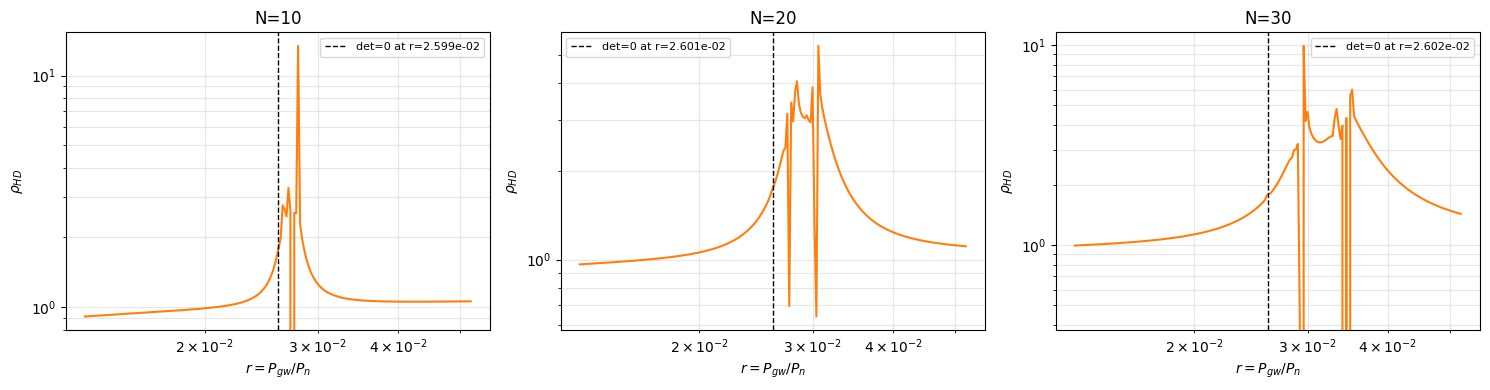

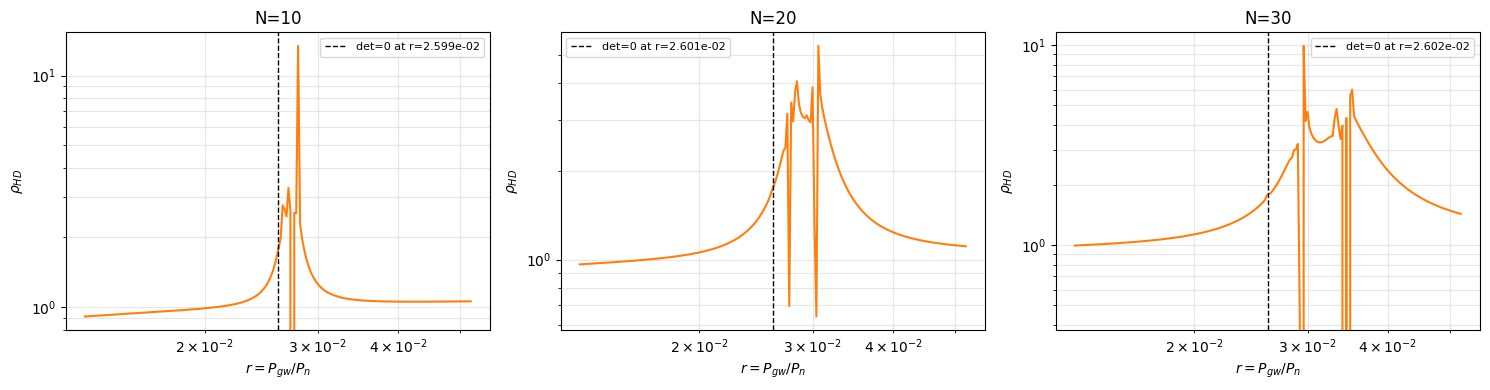

In [16]:

# Confirm these are really where rho_HD spikes (not just where det(M) happens to flip).
fig, axes = plt.subplots(1, len(small_Ns), figsize=(5 * len(small_Ns), 4), sharey=False)
for ax, N in zip(np.atleast_1d(axes), small_Ns):
    res = dense_results[N]
    spike = res['spikes'][0] if res['spikes'] else None
    if spike is not None:
        r_zoom = np.logspace(np.log10(spike) - 0.3, np.log10(spike) + 0.3, 200)
    else:
        r_zoom = res['r_grid']
    rho_zoom = rho_hd_full_matrix_dense(r_zoom, res['gamma'], verbose=False)
    ax.loglog(r_zoom, rho_zoom, color='C1')
    if spike is not None:
        ax.axvline(spike, color='k', ls='--', lw=1, label=f'det=0 at r={spike:.3e}')
    ax.set_title(f'N={N}')
    ax.set_xlabel(r'$r=P_{gw}/P_n$')
    ax.set_ylabel(r'$\rho_{HD}$')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.show()



## Section 2 — Does the diagonal of $M(r)$ go to zero?

From `rho_hd_full_matrix`'s own matrix-free path, the diagonal of $M(r)$ has the closed form

$$
M(r)_{ab,ab} \;=\; 1 + \frac{1}{\tilde F_{ab}^2}\left(1+\frac1r\right)^{2} .
$$

Since $\left(1+\tfrac1r\right)^2 \ge 0$ for any real $r>0$, this is bounded below by $1$ --
**the diagonal can never reach zero**, regardless of $N$ or geometry. That's confirmed
numerically below directly from the dense $A,B,D$ built for the small-$N$ cases above (the
same identity holds exactly, since the dense and matrix-free constructions must agree on
the diagonal).


In [27]:

for N in small_Ns:
    res = dense_results[N]
    _, A, B, D = build_HD_matrices(res['gamma'])
    diagA, diagB, diagD = np.diag(A), np.diag(B), np.diag(D)

    spike = res['spikes'][0] if res['spikes'] else None
    if spike is None:
        print(f"N={N}: no spike found in range -- skipping diagonal check")
        continue

    diagM_at_spike = diagA + diagB / spike + diagD / spike**2
    print(f"N={N}, spike r={spike:.4e}:  min(diag M) = {diagM_at_spike.min():.6f}   "
          f"max(diag M) = {diagM_at_spike.max():.6f}")

print("\ndiag(M(r)) stays of order 1-2 at every spike. The diagonal is NOT going to")
print("   zero. The singularity in det(M(r)) is coming from off-diagonal structure.")


N=10, spike r=2.5993e-02:  min(diag M) = 1.999692   max(diag M) = 2.082020
N=20, spike r=2.6005e-02:  min(diag M) = 1.998870   max(diag M) = 2.087680
N=30, spike r=2.6021e-02:  min(diag M) = 1.997543   max(diag M) = 2.096310

diag(M(r)) stays of order 1-2 at every spike. The diagonal is NOT going to
   zero. The singularity in det(M(r)) is coming from off-diagonal structure.



## Section 3 — Are the three HD cases canceling?

$M(r) = A + B/r + D/r^2$, where $A$ carries the case-1 (no shared star) contributions plus
the $r^0$ parts of the case-2/case-3 corrections, $B$ carries the $r^{-1}$ case-2 pieces,
and $D$ carries the $r^{-2}$ case-3 (diagonal) piece.

At the spike, $M(r)$ has (at least) one eigenvalue $\lambda \approx 0$ with eigenvector
$v$. Writing $v^\top M(r) v = v^\top A v + v^\top(B/r)v + v^\top(D/r^2)v$, we can check
directly whether the three pieces are individually $O(1)$ but sum to (near) zero -- i.e.
genuine cancellation between cases -- or whether one piece alone is already small.

We also split $A$ itself into its case-1-only and case-2-only contributions to see which
case combination is actually responsible.


In [18]:

def build_HD_matrices_with_case_masks(gamma_matrix):
    '''Same construction as build_HD_matrices, but also returns the case masks and the
    case-1-only piece of A, so contributions can be inspected separately.'''
    n_star = gamma_matrix.shape[0]
    pairs = np.array([(a, b) for a in range(n_star) for b in range(a + 1, n_star)])
    n_pairs = len(pairs)

    Fg_pair = F_PHYS * gamma_matrix[pairs[:, 0], pairs[:, 1]]
    Fg_mat = F_PHYS * gamma_matrix

    a_idx, b_idx = pairs[:, 0], pairs[:, 1]
    a_i, b_i = a_idx[:, None], b_idx[:, None]
    c_j, d_j = a_idx[None, :], b_idx[None, :]

    ac, bc, ad, bd = a_i == c_j, b_i == c_j, a_i == d_j, b_i == d_j
    case3 = ac & bd
    case1 = ~ac & ~bc & ~ad & ~bd
    case2 = ~case1 & ~case3

    Fg_ab, Fg_cd = Fg_pair[:, None], Fg_pair[None, :]
    Fg_ac, Fg_bd = Fg_mat[a_i, c_j], Fg_mat[b_i, d_j]
    Fg_ad, Fg_bc = Fg_mat[a_i, d_j], Fg_mat[b_i, c_j]

    A1_only = np.zeros((n_pairs, n_pairs))
    with np.errstate(divide='ignore', invalid='ignore'):
        A_c1 = (Fg_ac * Fg_bd + Fg_ad * Fg_bc) / (Fg_ab * Fg_cd)
    A1_only[case1] = A_c1[case1]

    pairs_out, A, B, D = build_HD_matrices(gamma_matrix)
    A2_only = A - A1_only  # everything in A that ISN'T the pure case-1 term

    return pairs_out, A, B, D, A1_only, A2_only, case1, case2, case3


In [19]:

for N in small_Ns:
    res = dense_results[N]
    spike = res['spikes'][0] if res['spikes'] else None
    if spike is None:
        continue

    pairs, A, B, D, A1_only, A2_only, case1, case2, case3 = build_HD_matrices_with_case_masks(res['gamma'])
    M = A + B / spike + D / spike**2
    eigvals, eigvecs = np.linalg.eigh(M)
    idx = np.argmin(np.abs(eigvals))
    v = eigvecs[:, idx]

    qA  = v @ A @ v
    qB  = v @ (B / spike) @ v
    qD  = v @ (D / spike**2) @ v
    qA1 = v @ A1_only @ v
    qA2 = v @ A2_only @ v

    print(f"--- N={N}, spike r={spike:.4e}, near-null eigenvalue={eigvals[idx]:.3e} ---")
    print(f"  v^T A v        = {qA:+.4f}   (case-1 + case-2/case-3 r^0 fixes)")
    print(f"    of which case-1-only : {qA1:+.4f}")
    print(f"           case-2/3 fix  : {qA2:+.4f}")
    print(f"  v^T (B/r) v    = {qB:+.4f}   (case-2, r^-1)")
    print(f"  v^T (D/r^2) v  = {qD:+.4f}   (case-3 / diagonal, r^-2)")
    print(f"  sum = v^T M v  = {qA+qB+qD:+.4e}   (should equal the near-null eigenvalue)")

    top = np.argsort(-np.abs(v))[:6]
    print("  pairs dominating the near-null eigenvector:")
    for k in top:
        a, b = pairs[k]
        print(f"    pair ({a},{b}):  component = {v[k]:+.4f}")
    print()


--- N=10, spike r=2.5993e-02, near-null eigenvalue=-1.114e-15 ---
  v^T A v        = +0.9647   (case-1 + case-2/case-3 r^0 fixes)
    of which case-1-only : +2.0155
           case-2/3 fix  : -1.0508
  v^T (B/r) v    = -1.9293   (case-2, r^-1)
  v^T (D/r^2) v  = +0.9646   (case-3 / diagonal, r^-2)
  sum = v^T M v  = -4.4409e-16   (should equal the near-null eigenvalue)
  pairs dominating the near-null eigenvector:
    pair (2,8):  component = -0.4641
    pair (0,6):  component = -0.3501
    pair (0,1):  component = +0.3481
    pair (0,2):  component = +0.2971
    pair (6,8):  component = +0.2914
    pair (0,7):  component = -0.2820

--- N=20, spike r=2.6005e-02, near-null eigenvalue=2.388e-15 ---
  v^T A v        = +0.9692   (case-1 + case-2/case-3 r^0 fixes)
    of which case-1-only : +2.0203
           case-2/3 fix  : -1.0510
  v^T (B/r) v    = -1.9378   (case-2, r^-1)
  v^T (D/r^2) v  = +0.9686   (case-3 / diagonal, r^-2)
  sum = v^T M v  = -1.1102e-16   (should equal the near-null 


**Reading the output:** if `v^T A v`, `v^T (B/r) v`, and `v^T (D/r^2) v` are each $O(1)$ in
magnitude but sum to something many orders of magnitude smaller, that is direct numerical
evidence that the spike comes from cancellation **between** the $r^0$, $r^{-1}$, and
$r^{-2}$ pieces (i.e. between the HD cases) along a specific direction in pair-space, not
from any single case or from the diagonal collapsing. The "pairs dominating the near-null
eigenvector" list also shows which stars are geometrically responsible. If there is a
small cluster of stars whose pairs all show up here, that could point to a
near-degenerate/near-collinear sub-configuration.



## Section 4 — Scaling to $N=100,\dots,1000$ without forming the dense matrix

For these $N$, $N_{\rm pairs}$ is far above `dense_cutover_pairs`, so $A,B,D$ can never be
built directly (e.g. $N=1000 \Rightarrow N_{\rm pairs}\approx 5\times10^5 \Rightarrow$ a
dense matrix would need $\sim 2\,\rm TB$). Everything below uses **only** the existing
matrix-free `make_hd_matvec` operator.

Strategy:
1. Locate the spike by **peak-finding** on $\rho_{\rm HD}(r)$ itself (computed via the
   existing MINRES solve, on a modest log-spaced grid), then zoom in with a local
   golden-section-style refinement -- no dense matrix, no full fine-grained sweep.
2. Reuse the **solution vector** from the MINRES solve near the spike as an approximate
   near-null eigenvector (as $r\to r_{\rm spike}$, $M(r)^{-1}\mathbf 1$ becomes dominated by
   the near-null eigenvector, since $M(r)^{-1}\mathbf 1$ blows up along that direction).
3. Split the matvec algebraically into its $A$, $B$, $D$ pieces (same three groupings as
   the dense path, verified to sum back to `make_hd_matvec`'s output) so the case-cancellation
   check from Section 3 can be repeated **without ever forming a dense matrix**.


In [20]:

def _hd_matvec_pieces(data, r):
    '''Return three matvecs (A-only, B-only, D-only) whose r-weighted sum reproduces
    make_hd_matvec(data, r) exactly (verified algebraically against hd_full_matrix_snr.py).'''
    a_idx, b_idx, Fab, F = data.a_idx, data.b_idx, data.Fab, data.F
    n_pairs = data.n_pairs

    def shared_pieces(x):
        X = np.zeros_like(F)
        x_scaled = x / Fab
        X[a_idx, b_idx] = x_scaled
        X[b_idx, a_idx] = x_scaled
        U = F @ X
        S = U @ F
        diag_U = np.diag(U)
        row_sum = np.bincount(a_idx, weights=x, minlength=F.shape[0])
        row_sum += np.bincount(b_idx, weights=x, minlength=F.shape[0])
        case2_term = (U[a_idx, b_idx] + U[b_idx, a_idx]) / Fab
        return S, diag_U, row_sum, case2_term

    def matvec_A(x):
        x = np.asarray(x, dtype=float)
        S, diag_U, row_sum, case2_term = shared_pieces(x)
        return (S[a_idx, b_idx] / Fab - diag_U[a_idx] - diag_U[b_idx]
                + row_sum[a_idx] + row_sum[b_idx] + case2_term + x / (Fab * Fab))

    def matvec_B(x):
        x = np.asarray(x, dtype=float)
        _, _, _, case2_term = shared_pieces(x)
        return case2_term + 2.0 * x / (Fab * Fab)

    def matvec_D(x):
        x = np.asarray(x, dtype=float)
        return x / (Fab * Fab)

    return matvec_A, matvec_B, matvec_D


def raw_rho_sq_matrix_free(data, r, x0=None, rtol=1e-11, maxiter=8000):
    '''Solve M(r) x = 1 via MINRES (matrix-free) and return the RAW (unclipped) rho^2,
    plus the solution vector, so sign flips / blow-ups near a spike are visible.'''
    n = data.n_pairs
    matvec = make_hd_matvec(data, r)
    Aop = LinearOperator((n, n), matvec=matvec, dtype=float)

    diag = 1.0 + 1.0 / (data.Fab**2) + 2.0 / (r * data.Fab**2) + 1.0 / (r * r * data.Fab**2)
    inv_diag = 1.0 / diag
    Mop = LinearOperator((n, n), matvec=lambda v: inv_diag * np.asarray(v, dtype=float), dtype=float)

    ones = np.ones(n)
    sol, info = minres(Aop, ones, M=Mop, rtol=rtol, maxiter=maxiter, x0=x0)
    rho_sq = 2.0 * float(np.sum(sol))
    return rho_sq, sol, info


In [21]:

def find_spike_matrix_free(gamma_matrix, r_lo=1e-4, r_hi=1e1, n_coarse=80, verbose=False):
    '''Locate the r where rho_HD(r) spikes, using only matrix-free evaluations.

    Coarse log-grid -> peak-find on log(rho) -> local refine (golden-section-ish
    bisection maximizing rho) around the tallest peak. Returns (r_grid, rho_grid, r_spike).
    '''
    data = build_hd_pair_data(gamma_matrix)
    r_grid = np.logspace(np.log10(r_lo), np.log10(r_hi), n_coarse)

    rho_grid = np.empty(n_coarse)
    x0 = None
    for i, r in enumerate(r_grid):
        rho_sq, sol, info = raw_rho_sq_matrix_free(data, r, x0=x0)
        x0 = sol if info == 0 else None
        rho_grid[i] = np.sqrt(max(rho_sq, 0.0))
        if verbose:
            print(f"    r={r:.4e}  rho_HD={rho_grid[i]:.4e}  info={info}")

    peaks, _ = find_peaks(np.log(np.maximum(rho_grid, 1e-300)))
    if len(peaks) == 0:
        if verbose:
            print("    no interior peak found in this r-range")
        return r_grid, rho_grid, None, data

    # refine around the most prominent peak with a local ternary-search-style zoom
    peak_idx = peaks[np.argmax(rho_grid[peaks])]
    lo = r_grid[max(peak_idx - 1, 0)]
    hi = r_grid[min(peak_idx + 1, n_coarse - 1)]

    for _ in range(30):
        m1 = lo * (hi / lo) ** (1 / 3)
        m2 = lo * (hi / lo) ** (2 / 3)
        rho_m1, sol1, _ = raw_rho_sq_matrix_free(data, m1, x0=x0)
        rho_m2, sol2, _ = raw_rho_sq_matrix_free(data, m2, x0=x0)
        if abs(rho_m1) > abs(rho_m2):
            hi = m2
            x0 = sol1
        else:
            lo = m1
            x0 = sol2

    r_spike = np.sqrt(lo * hi)
    return r_grid, rho_grid, r_spike, data



### Run the scalable spike finder for $N=100,200,\dots,1000$

This only ever holds vectors of length $N_{\rm pairs}$ in memory (never an
$N_{\rm pairs}\times N_{\rm pairs}$ matrix). Results are checkpointed to
`hd_spike_sweep_results.npz` after every $N$, so a long sweep isn't lost if it's
interrupted - re-running the cell will skip any $N$ already saved.



In [23]:

N_values = list(range(100, 901, 100))   # adjust as needed -- see runtime note above
seed_retries = [RANDOM_SEED, RANDOM_SEED + 1, RANDOM_SEED + 2]  # tried in order per N
checkpoint_path = "hd_spike_sweep_results.npz"

if os.path.exists(checkpoint_path):
    _ckpt = dict(np.load(checkpoint_path, allow_pickle=True))
    spike_results = {int(k): v.item() for k, v in _ckpt.items()}
    print(f"Loaded {len(spike_results)} cached results from {checkpoint_path}")
else:
    spike_results = {}

for N in N_values:
    if N in spike_results:
        print(f"N={N}: using cached result (r_spike={spike_results[N]['r_spike']}, "
              f"seed={spike_results[N].get('seed')})")
        continue

    t0 = time.time()
    r_spike, used_seed, n_pairs = None, None, None
    for seed in seed_retries:
        gamma, ell_min, ell_max = build_gamma_for_N(N, seed=seed, verbose=True)
        r_grid, rho_grid, r_spike_try, data = find_spike_matrix_free(gamma, verbose=False)
        n_pairs = data.n_pairs
        if r_spike_try is not None:
            r_spike, used_seed = r_spike_try, seed
            break
        print(f"    seed={seed}: no spike in scanned r-range, trying next seed...")
    dt = time.time() - t0

    spike_results[N] = dict(r_spike=r_spike, n_pairs=n_pairs, runtime_s=dt, seed=used_seed)
    print(f"N={N}: n_pairs={n_pairs}, r_spike={r_spike} (seed={used_seed}), total time={dt:.1f}s")

    # checkpoint after every N
    np.savez(checkpoint_path, **{str(k): v for k, v in spike_results.items()})


Loaded 9 cached results from hd_spike_sweep_results.npz
N=100: using cached result (r_spike=0.11471923087970126, seed=1234)
N=200: using cached result (r_spike=None, seed=None)
N=300: using cached result (r_spike=None, seed=None)
N=400: using cached result (r_spike=0.02638644957704243, seed=1234)
N=500: using cached result (r_spike=0.02647927800390787, seed=1234)
N=600: using cached result (r_spike=0.02656971130600725, seed=1234)
N=700: using cached result (r_spike=0.026612066245190937, seed=1234)
N=800: using cached result (r_spike=0.02674803753688864, seed=1234)
N=900: using cached result (r_spike=0.026805658344579937, seed=1234)


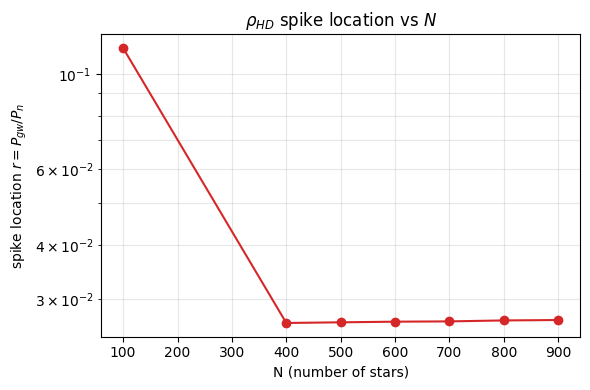

In [24]:

Ns_done = sorted(spike_results.keys())
spikes_done = [spike_results[N]['r_spike'] for N in Ns_done]

fig, ax = plt.subplots(figsize=(6, 4))
valid = [(N, s) for N, s in zip(Ns_done, spikes_done) if s is not None]
if valid:
    Ns_plot, spikes_plot = zip(*valid)
    ax.semilogy(Ns_plot, spikes_plot, 'o-', color='C3')
ax.set_xlabel('N (number of stars)')
ax.set_ylabel(r'spike location $r = P_{gw}/P_n$')
ax.set_title(r'$\rho_{HD}$ spike location vs $N$')
ax.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.show()



## Section 5 — Diagonal & case-cancellation check at scale

Same two checks as Sections 2-3, but now done matrix-free for the large-$N$ cases:

- **Diagonal**: still the closed form $1 + (1+1/r)^2/\tilde F_{ab}^2$ -- no matrix needed,
  and it's positive by construction for every $N$, so this is checked analytically once
  and doesn't need to be repeated per $N$ (it can't fail).
- **Case cancellation**: use the MINRES solution vector at (very near) the spike as the
  approximate near-null direction $v \approx \mathrm{sol}/\|\mathrm{sol}\|$, then compute
  $v^\top A v$, $v^\top (B/r) v$, $v^\top (D/r^2) v$ via the matvec-only `matvec_A/B/D`
  helpers above (no dense matrix formed).


In [25]:

for N in Ns_done:
    r_spike = spike_results[N]['r_spike']
    if r_spike is None:
        continue
    seed_used = spike_results[N].get('seed', RANDOM_SEED)

    gamma, ell_min, ell_max = build_gamma_for_N(N, seed=seed_used)
    data = build_hd_pair_data(gamma)
    matvec_A, matvec_B, matvec_D = _hd_matvec_pieces(data, r_spike)

    # solve very close to the spike to get a solution vector dominated by the near-null direction
    r_probe = r_spike * (1 + 1e-6)
    rho_sq, sol, info = raw_rho_sq_matrix_free(data, r_probe)
    v = sol / (np.linalg.norm(sol) + EPS)

    qA = float(v @ matvec_A(v))
    qB = float(v @ matvec_B(v)) / r_spike
    qD = float(v @ matvec_D(v)) / (r_spike ** 2)

    print(f"--- N={N}, spike r={r_spike:.4e} ---")
    print(f"  v^T A v        = {qA:+.4f}")
    print(f"  v^T (B/r) v    = {qB:+.4f}")
    print(f"  v^T (D/r^2) v  = {qD:+.4f}")
    print(f"  sum            = {qA+qB+qD:+.4e}  (near zero => cancellation between cases)")
    print()


--- N=100, spike r=1.1472e-01 ---
  v^T A v        = +0.2174
  v^T (B/r) v    = -0.2677
  v^T (D/r^2) v  = +0.0503
  sum            = +1.1176e-06  (near zero => cancellation between cases)

--- N=400, spike r=2.6386e-02 ---
  v^T A v        = +0.9591
  v^T (B/r) v    = -1.9167
  v^T (D/r^2) v  = +0.9575
  sum            = +4.9857e-06  (near zero => cancellation between cases)

--- N=500, spike r=2.6479e-02 ---
  v^T A v        = +0.9532
  v^T (B/r) v    = -1.9040
  v^T (D/r^2) v  = +0.9509
  sum            = +6.7814e-06  (near zero => cancellation between cases)

--- N=600, spike r=2.6570e-02 ---
  v^T A v        = +0.9461
  v^T (B/r) v    = -1.8906
  v^T (D/r^2) v  = +0.9444
  sum            = +7.3477e-06  (near zero => cancellation between cases)

--- N=700, spike r=2.6612e-02 ---
  v^T A v        = +0.9399
  v^T (B/r) v    = -1.8812
  v^T (D/r^2) v  = +0.9412
  sum            = +4.8334e-06  (near zero => cancellation between cases)

--- N=800, spike r=2.6748e-02 ---
  v^T A v       

KeyboardInterrupt: 


## Summary

- **Section 1** pins down the exact $r$ where $\det M(r)=0$ for a few small $N$ (ground
  truth), and confirms visually that $\rho_{\rm HD}(r)$ genuinely spikes there.
- **Section 2** shows the diagonal of $M(r)$ has a closed form that is always $\ge 1$ -
  the diagonal is not the origin of the spike.
- **Section 3** decomposes the near-null eigenvector's quadratic form into the $A$
  ($r^0$), $B$ ($r^{-1}$), $D$ ($r^{-2}$) pieces (and further splits $A$ into its
  case-1-only vs. case-2/3-fix parts) to show whether/where cancellation between the HD
  cases occurs, and identifies which stars/pairs dominate the near-singular direction.
- **Sections 4-5** repeat the location + cancellation checks for $N=100$-$1000$ using only
  the matrix-free operator, so the same diagnosis can be extended to the full range of
  interest without the $O(N_{\rm pairs}^2)$ memory cost of forming $A,B,D$ explicitly.


